# For 3 RDPGs

In [1]:
# import everything
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

from graspologic.embed import AdjacencySpectralEmbed
from graspologic.simulations import sbm
from graspologic.plot import heatmap, pairplot

import warnings
warnings.filterwarnings('ignore')
np.random.seed(8889)
import matplotlib.lines as mlines
%matplotlib inline

import networkx as nx
from scipy.sparse import csr_array
from graspologic.simulations import rdpg
#from scipy.linalg import irlba
#from scipy.spatial import procrustes
%run GraphEncoder.ipynb
import leidenalg as la
import igraph as ig
import scipy.sparse as sp
import random
import math
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from gae.layers import GraphConvolution
from gae.model import GCNModelVAE
from gae.utils import load_data, mask_test_edges, preprocess_graph, get_roc_score
from gae.optimizer import loss_function

/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1086: NumbaDeprecatio

In [2]:
# Define all the functions 
def sample_dot_product(lpvs):
        num_nodes = lpvs.shape[1]
        similarity_matrix = np.dot(lpvs.T, lpvs)
        np.fill_diagonal(similarity_matrix, 0)  # Remove self-similarity
        return nx.Graph(similarity_matrix)

def adj_to_edg(A):
    """
      input is the symmetric adjacency matrix: A
      other variables in this function:
      s: number of edges
      return edg_list -- matrix format with shape(edg_sum,3):
      example row in edg_list(matrix): [vertex1, vertex2, connection weight from Adj matrix]
    """
    # check the len of the second dimenson of A
    if A.shape[1] <= 3:
      edg = A
    else:
      n = A.shape[0]
      # construct the initial edgg_list matrix with the size of (edg_sum, 3)
      edg_list = []
      for i in range(n):
        for j in range(i, n):
          if A[i,j] > 0:
            row = [i, j, A[i,j]]
            edg_list.append(row)
      edg = np.array(edg_list)
    return edg

def procrustes(X, Y, type="I"):
    if type == "C":
        X = X / np.linalg.norm(X, "fro") * np.sqrt(X.shape[0])
        Y = Y / np.linalg.norm(Y, "fro") * np.sqrt(Y.shape[0])
    if type == "D":
        tX = np.sum(X ** 2, axis=1)
        tX[tX <= 1e-15] = 1
        tY = np.sum(Y ** 2, axis=1)
        tY[tY <= 1e-15] = 1
        X = X / np.sqrt(tX)[:, np.newaxis]
        Y = Y / np.sqrt(tY)[:, np.newaxis]

    tmp = X.T @ Y
    U, s, Vt = np.linalg.svd(tmp,full_matrices=True)
    W = U @ Vt ########
    error = np.linalg.norm(X @ W - Y, "fro")
    
    return {"error": error, "W": W}

def GCN_emb(model, features, adj_norm_matrix, adj_label,n, decay,learning_rate, epochs = 200):
    optimizer = torch.optim.Adam(
      model.parameters(),
      lr=learning_rate,
      weight_decay=decay) #weight decay is important!

    # get class weight
    pos_weight = ((adj_label.shape[0] * adj_label.shape[0] - adj_label.sum()) / adj_label.sum())
    # get adj norm
    adj_norm = adj_label.shape[0] * adj_label.shape[0] / float((adj_label.shape[0] *adj_label.shape[0] - adj_label.sum()) * 2)

    # Training the VAE   
    while True: #we can try 20 different random weight init runs to get an average 
        # initialize weights randomly => impact on convergence
        model.gc1.reset_parameters()
        model.gc2.reset_parameters()
        model.gc3.reset_parameters()  
        # Training
        for epoch in range(0, epochs + 1):
            model.train()
            optimizer.zero_grad()
            # ===================forward=====================
            adj_hat, mu, logvar = model(features,adj_norm_matrix)        
            loss = loss_function(adj_hat,adj_label,mu,logvar,n,adj_norm,pos_weight) #might reduce the KL term regularization
            # log
            if epoch == 0:
              init_loss = loss.item()
            # if epoch% 50 == 0:
            #   print('loss: ', loss.item())
            # ===================backward====================
            loss.backward()
            optimizer.step()
        # Check convergence
        if (init_loss-loss.item())/loss.item() > 0.05: 
            break
        else:
          print(model)
          print('not converged yet, reset params and rerun')

  # Get GCN embedding
    with torch.no_grad():
      model.eval()
      adj_hat, mu, logvar = model(features, adj_norm_matrix)
      z = model.reparameterize(mu, logvar) 

    return z

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def preprocess_graph(adj_):
    rowsum = np.array(adj_.sum(1))
    degree_mat_inv_sqrt = sp.diags(np.power(rowsum, -0.5).flatten()) #D^-0.5
    adj_normalized = adj_.dot(degree_mat_inv_sqrt).transpose().dot(degree_mat_inv_sqrt).tocoo()  #D^-0.5 A D^-0.5
    return sparse_mx_to_torch_sparse_tensor(adj_normalized), sparse_mx_to_torch_sparse_tensor(adj_)

def adj_in_out(adj):
    row, col = np.where(adj)
    coo = np.rec.fromarrays([row, col, adj[row, col]], names='row col value'.split())
    out = sp.coo_matrix((coo['value'], (coo['row'], coo['col'])), (adj.shape[0], adj.shape[1]))
    #Adjacency normalized matrix and label for GVAE usage
    adj_norm_matrix, adj_matrix = preprocess_graph(out)
    adj_label = torch.FloatTensor(out.toarray())
    return adj_norm_matrix, adj_matrix, adj_label#, out

def ARDPG(n,k):
    A = np.zeros((n,n))
    X = np.random.uniform(0.0, 1.0, (n,1))
    for i in range(0,n):
        if y[i] == 1:
            X[i,:] = np.random.beta(1,3)
        elif y[i] == 2:
            X[i,:] = np.random.beta(3,3)
        else:
            X[i,:] = np.random.beta(3,1)
    P=np.matmul(X,X.transpose())
    for i in range(0,n):
        for j in range(1,n):
            A[i,j]=np.random.binomial(1,P[i,j])
    for i in range(0,n):
        for j in range(0,i):
            A[i,j] = A[j,i]
            A[i,i]=0
    return A

def gety(n):
    y = np.zeros((n,1))
    #np.random.seed(2)
    for i in range(0,n):
        y[i,0] = np.random.choice(np.arange(1, 4), p=[0.2, 0.3,0.5])
    return(y)

def latent3y(n):
    X1 = np.random.dirichlet((2,1,1),int(n/3))
    X2 = np.random.dirichlet((1,1,2),int(n/3))
    X3 = np.random.dirichlet((1,2,1),(n-int(n/3)*2))
    together = np.concatenate((X1, X2,X3))
    latent = np.delete(together, 2, 1)
    ty = [1,2,3]
    y = np.repeat(ty, n/3)
    return(latent,y)
  

In [105]:
# RDPG 3 cluster
# calculate row sum
# R^3
# Adj clique

#nvs = np.arange(100, 1501, 200)

nvs = np.arange(1000, 1001, 2)

d = 3
sim = 50  #50
random.seed(118)

ASE_dist = []
ASE_nml = []
GEE_dist = []
GEE_nml = []
GAE_dist = []
GAE_nml = []
n_vs = []

GEE_fnorm = []
GAE_fnorm = []

adj0_norms = []

sim_alldata_nml = []

RSD_afterASE = []
RSD_afterGEE1 = []
RSD_afterGAE = []

for n in nvs:
    ########## change clique size ################################
    ratio = 0.2      
    cliquesize =f'log^2' #f'log(n)'      #!!    f'{ratio}*n'
    clique_size = math.sqrt(n)  # math.sqrt(n)  # math.log(n)           #   ratio*n 
    num_vertices = int(clique_size) 
    #################  change location of vertices##################
    #c_vertices = np.arange(0,num_vertices)  
    #c_vertices = np.arange(n-num_vertices,n)  
    c_vertices = random.sample(range(0,n),num_vertices)
    MRRs1,MRRs2,MRRs3,MRRs4 = [], [], [], []
    for i in range(sim):
        #lpvs = np.random.dirichlet((1,1,1),n) 
        #lpvs = np.delete(lpvs, 2, 1)
        
        #g = rdpg(lpvs,loops=False)
        latent, ys = latent3y(n)
        g = rdpg(latent,loops=False)
        
        g.astype(int)
        adj0 = csr_array(g)
        graph0 = nx.from_numpy_matrix(g,parallel_edges=False, create_using=None)
        
        adj0_norm = sp.linalg.norm(adj0)
        adj0_norms.append(adj0_norm)

#         ########## change clique size ################################
#         ratio = 0.2      
#         cliquesize =f'log^2' #f'log(n)'      #!!    f'{ratio}*n'
#         clique_size = math.log(n)**2 # math.log(n)           #   ratio*n 
#         num_vertices = int(clique_size) 
#         #################  change location of vertices##################
#         #c_vertices = np.arange(0,num_vertices)  
#         #c_vertices = np.arange(n-num_vertices,n)  
#         c_vertices = random.sample(range(0,n),num_vertices)
#         ################################################################
        full_g = nx.complete_graph(c_vertices)
        
        full_edges = list(full_g.edges())
        edges = list(graph0.edges()) 
        all_edges = set(full_edges).union(set(edges))
        
        graph1 = nx.Graph()
        graph1.add_nodes_from(sorted(graph0.nodes(data=True)))
        graph1.add_edges_from(all_edges)
        #graph1 = nx.Graph(all_edges)
        #graph1.add_nodes_from(list(graph0.nodes- graph1.nodes))
        #graph1 = nx.compose(full_g,graph0)

        adj1 = nx.to_numpy_array(graph1, dtype=int)

        ##############  ASE  ######################3
        d = 3
        ase = AdjacencySpectralEmbed(n_components=d, algorithm='truncated')
        ASE_Xhat0 = ase.fit_transform(adj0)

        ASE_Xhat1 = ase.fit_transform(adj1)

        #pairplot(Xhat0, title='2-component embedding', height=2)
        ASE_d = procrustes(ASE_Xhat1,ASE_Xhat0)
        ASE_dt = ASE_d['error']
        ASE_dist.append(ASE_dt)
        
        ASE_n = ASE_dt/adj0_norm
        ASE_nml.append(ASE_n)
        
        ############## row sum after ASE
        
        row_1 = np.sum((ASE_Xhat0 - ASE_Xhat1.dot(ASE_d['W']))**2, axis=1)
        RSD_afterASE.append(row_1)

        ############ GEE ##################
        n_comms = 3
        edgelist0 = adj_to_edg(adj0)
        i_graph0 = ig.Graph.from_networkx(graph0)
        #y0 = la.find_partition(i_graph0, la.ModularityVertexPartition)
        #y0 = la.find_partition(i_graph0,la.CPMVertexPartition,resolution_parameter = 0.015)
        y0 = la.CPMVertexPartition(i_graph0,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        label_num = []
        for k in range(len(y0)):
            y = len(y0[k])
            label_num.append(y)
        values = np.arange(len(label_num))
        label0 = np.repeat(values, label_num) 
        label0= label0.reshape((n,1))
        Z0,W0 = graph_encoder_embed(edgelist0,label0,n,correlation=False,emb_opt='AEE')

        edgelist1 = adj_to_edg(adj1)
        i_graph1 = ig.Graph.from_networkx(graph1)
        
        y1 = la.CPMVertexPartition(i_graph1,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        
        label_num1 = []
        for j in range(len(y1)):
            y = len(y1[j])
            label_num1.append(y)
        values1 = np.arange(len(label_num1))
        label1 = np.repeat(values1, label_num1) 
        label1= label1.reshape((n,1))
        Z1,W1 = graph_encoder_embed(edgelist1,label1,n,correlation=False,emb_opt='AEE')

        GEE_d = procrustes(Z1,Z0)
        GEE_dt = GEE_d['error']
        GEE_dist.append(GEE_dt)
        
        GEE_n = GEE_dt/adj0_norm
        GEE_nml.append(GEE_n)
        
        GEE_fd = np.linalg.norm(Z0 - Z1, "fro")
        GEE_fnorm.append(GEE_fd)
        
        ############## row sum after GEE
        
        row_2 = np.sum((Z0 - Z1.dot(GEE_d['W']))**2, axis=1)
        RSD_afterGEE1.append(row_2)
        
        
        ############### VGAE ################
        dim = 3
        features = torch.eye(n)
        model_GAE = GCNModelVAE(n, 2*dim, dim, 0) #init new instance everytime. Can change 0 to other dropout rates
        
        adj0 = nx.to_numpy_array(graph0, dtype=int)
        adj_norm_matrix0, adj_matrix0, adj_label0 = adj_in_out(adj0)
        GAE_0 = GCN_emb(model_GAE, features, adj_norm_matrix0, adj_label0,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_0 = GAE_0.numpy()
        adj1 = nx.to_numpy_array(graph1, dtype=int)
        adj_norm_matrix1, adj_matrix1, adj_label1 = adj_in_out(adj1)
        GAE_1 = GCN_emb(model_GAE, features, adj_norm_matrix1, adj_label1,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_1 = GAE_1.numpy()
        GAE_d = procrustes(GAE_1,GAE_0)
        GAE_d = GAE_d['error']
        GAE_dist.append(GAE_d)
        
        GAE_n = GAE_d/adj0_norm
        GAE_nml.append(GAE_n)
        
        GAE_fd = np.linalg.norm(GAE_0 - GAE_1, "fro")
        GAE_fnorm.append(GAE_fd)
        
        ############# row sum after VGAE
        row_4 = np.sum((GAE_0 - GAE_1)**2, axis=1)
        RSD_afterGAE.append(row_4)
        
        n_vs.append(n)
        
#------------------------ MRRS
        sorted_indices1 = np.argsort(row_1)[::-1]
        sorted_indices2 = np.argsort(row_2)[::-1]
        # sorted_indices3 = np.argsort(row_3)[::-1]
        sorted_indices4 = np.argsort(row_4)[::-1]
        ranks1 = []
        ranks2 = []
        ranks3 = []
        ranks4 = []
        for v in c_vertices:
            rank1 = np.where(sorted_indices1 == v)[0][0] + 1  # 1-based index
            ranks1.append(rank1)
            rank2 = np.where(sorted_indices2 == v)[0][0] + 1
            ranks2.append(rank2)
            # rank3 = np.where(sorted_indices3 == v)[0][0] + 1
            # ranks3.append(rank3)
            rank4 = np.where(sorted_indices4 == v)[0][0] + 1
            ranks4.append(rank4)

        reciprocals1 = [1 / r for r in ranks1]
        reciprocals2 = [1 / r for r in ranks2]
        reciprocals3 = [1 / r for r in ranks3]
        reciprocals4 = [1 / r for r in ranks4]
        MRRs1.append(np.mean(reciprocals1))
        MRRs2.append(np.mean(reciprocals2))
        # MRRs3.append(np.mean(reciprocals3))
        MRRs4.append(np.mean(reciprocals4))

#----------------------------


#     sim_data = np.column_stack((ASE_dist, GEE_dist,GAE_dist,
#                                 ASE_nml,GEE_nml,GAE_nml,n_vs,
#                                 GEE_fnorm,GAE_fnorm,adj0_norms))
#     sim_data = pd.DataFrame(sim_data, columns = ['ASE_dist','GEE_dist','VGAE_dist',
#                                                  'ASE_nml','GEE_nml','GAE_nml','n',
#                                                  'GEE_fnorm','VGAE_Fnorm','adj0_norms'])
    
#     df_id = n.astype(str)
#     sim_data.to_csv("./sim_data/new_sim/rdpg3cluster_log2"+cliquesize+df_id+".csv", sep=',', index=False)
    
# sim_alldata_nml.append(sim_data)


#print(sim_alldata_nml)



GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 6)
  (gc2): GraphConvolution (6 -> 3)
  (gc3): GraphConvolution (6 -> 3)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 6)
  (gc2): GraphConvolution (6 -> 3)
  (gc3): GraphConvolution (6 -> 3)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun


In [5]:
test1 = []
for x in RSD_afterASE:
    tt = np.sort(x)
    test1.append(tt)

p1=np.mean(test1,axis=0)
sortedASE = np.sort(p1)[::-1]
indexs = list(range(len(sortedASE)))

test2 = []
for x in RSD_afterGEE1:
    tt = np.sort(x)
    test2.append(tt)

p2=np.mean(test2,axis=0)
sorted_GEE1 = np.sort(p2)[::-1]
    
test3 = []
for x in RSD_afterGAE:
    tt = np.sort(x)
    test3.append(tt)

p3=np.mean(test3,axis=0)
sorted_GAE = np.sort(p3)[::-1]
len(RSD_afterGEE1)

10

In [106]:
# print MRRs
print(np.mean(MRRs1) )
print(np.mean(MRRs2))
print(np.mean(MRRs3))
print(np.mean(MRRs4))

0.1268819732718224
0.04403674116283084
nan
0.016420405180287777


In [107]:
#### 8/27 average then sort and highlight the stars
# Compute average RSD directly, no sorting first
p1 = np.mean(RSD_afterASE, axis=0)
p2 = np.mean(RSD_afterGEE1, axis=0)
# p3 = np.mean(RSD_afterGEE2, axis=0)
p4 = np.mean(RSD_afterGAE, axis=0)

sortedASE = np.sort(p1)[::-1]
sorted_indices = np.argsort(p1)[::-1] 
highlight_positions_p1 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p1 = [sortedASE[i] for i in highlight_positions_p1]


sorted_GEE1 = np.sort(p2)[::-1]
sorted_indices = np.argsort(p2)[::-1] 
highlight_positions_p2 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p2 = [sorted_GEE1[i] for i in highlight_positions_p2]


# sorted_GEE2 = np.sort(p3)[::-1]
# sorted_indices = np.argsort(p3)[::-1] 
# highlight_positions_p3 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
# highlight_values_p3 = [sorted_GEE2[i] for i in highlight_positions_p3]


sorted_GAE = np.sort(p4)[::-1]
sorted_indices = np.argsort(p4)[::-1] 
highlight_positions_p4 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p4 = [sorted_GAE[i] for i in highlight_positions_p4]

# Indices for plotting (after final sort)
indexs = list(range(len(sortedASE)))


In [56]:
# CAUTION store the values
Ac_3rdpg_02n = [test1,test2,test3]

In [101]:
# ZOOM plot
# draw the zoomed part 
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset,inset_axes

zoomgee = sorted_GEE1[0:30]
zoomase = sortedASE[0:30]
indexzoom = list(range(len(zoomgee)))


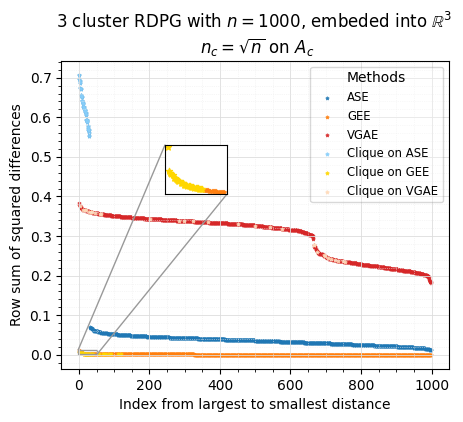

In [110]:

fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(True)
ax.grid(which='major', color='#DDDDDD', linewidth=0.6)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.set_xlabel('Index from largest to smallest distance')
ax.set_ylabel('Row sum of squared differences')
ax.set_title('3 cluster RDPG with $n=1000$, embeded into $\mathbb{R}^3$ \n $n_c =\sqrt{n} $ on $A_c$', ###____\sqrt{n}_______
             fontsize=12)

plt.scatter(indexs,sortedASE,marker = '*',color = '#1f77b4',alpha = 0.8,s = 4,label = "ASE")
plt.scatter(indexs,sorted_GEE1,marker = '*',color = '#ff7f0e',alpha = 0.8,s = 4,label = "GEE")
#plt.scatter(indexs,sorted_GEE2,marker = '*',color = '#2ca02c',alpha = 0.8,s = 4,label = 'GEE2')
plt.scatter(indexs,sorted_GAE,marker = '*',color = '#d62728',alpha = 0.8,s = 4,label = "VGAE")

# 8/27/2025 added started parts
#---------------
plt.scatter(highlight_positions_p1, highlight_values_p1,
            marker='*', color='lightskyblue', s=5,alpha = 0.8,label='Clique on ASE')# label='C vertices')
plt.scatter(highlight_positions_p2, highlight_values_p2,
            marker='*', color='gold', s=5,alpha = 0.8,label='Clique on GEE')# label='C vertices')
# plt.scatter(highlight_positions_p3, highlight_values_p3,
#             marker='*', color='#FFD700', s=20)# label='C vertices')
plt.scatter(highlight_positions_p4, highlight_values_p4,
            marker='*', color='peachpuff', s=5,alpha = 0.8,label='Clique on VGAE')# label='C vertices')

#---------------

legend = plt.legend(frameon = 1,loc = 1,title="Methods",
                    fontsize='small',fancybox=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')
frame.set_alpha(0.3)

# a = plt.axes([0.3, 0.6, .2, .2], facecolor='w')
# #plt.scatter(indexzoom,zoomase,marker = '*',color = '#1f77b4',alpha = 0.8)
# plt.scatter(indexzoom,zoomgee,marker = '*',color = '#ff7f0e',alpha = 0.8)
# #plt.title('Zoomed GEE',fontsize = 'small')
# plt.xticks([])
# plt.yticks([])
# mark_inset(ax, a, loc1=2, loc2=4, fc="none", ec="0.6")
# === Inset (zoomed-in plot) ===
axins = inset_axes(ax, width="40%", height="40%", loc='upper left',
                   bbox_to_anchor=(0.25, 0.35, 0.4, 0.4), bbox_transform=ax.transAxes)
# zoom region: first 50 points
zoom_range = slice(0, 50)
zoom_x = indexs[zoom_range]
zoom_y = sorted_GEE1[zoom_range]
# Highlighted points within zoom
zoom_highlight_x = [i for i in highlight_positions_p1 if i < 50]
zoom_highlight_y = [sorted_GEE1[i] for i in zoom_highlight_x]
# Inset plot
axins.scatter(zoom_x, zoom_y, marker='*', color='#ff7f0e', alpha=0.8, s=8)
axins.scatter(zoom_highlight_x, zoom_highlight_y, marker='*', color='gold', s=20)
axins.set_xticks([])
axins.set_yticks([])
# Connect inset to main plot
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.6")

# plt.savefig('./plots/rowsum/Ac_3rdpg_sqrtn_stars.png')
# plt.show()


In [66]:
# for 1 run, mark the clique vertices
sorted_with_indices = sorted(enumerate(RSD_afterASE[0]), key=lambda x: -x[1])
sorted_indices = [i for i, val in sorted_with_indices]
sorted_values = [val for i, val in sorted_with_indices]
highlight_original_indices = c_vertices          # indices 0 to 29
highlight_values = RSD_afterASE[0][c_vertices]
highlight_sorted_positions_ase = [i for i, orig_idx in enumerate(sorted_indices) if orig_idx in highlight_original_indices]
highlight_sorted_values_ase = [sorted_values[i] for i in highlight_sorted_positions_ase]

sorted_with_indices = sorted(enumerate(RSD_afterGEE1[0]), key=lambda x: -x[1])
sorted_indices = [i for i, val in sorted_with_indices]
sorted_values = [val for i, val in sorted_with_indices]
highlight_original_indices = c_vertices            # indices 0 to 29
highlight_values = RSD_afterGEE1[0][c_vertices]
highlight_sorted_positions_gee1 = [i for i, orig_idx in enumerate(sorted_indices) if orig_idx in highlight_original_indices]
highlight_sorted_values_gee1 = [sorted_values[i] for i in highlight_sorted_positions_gee1]

# sorted_with_indices = sorted(enumerate(RSD_afterGEE2[0]), key=lambda x: -x[1])
# sorted_indices = [i for i, val in sorted_with_indices]
# sorted_values = [val for i, val in sorted_with_indices]
# highlight_original_indices = list(range(30))             # indices 0 to 29
# highlight_values = RSD_afterGEE2[0][0:30]
# highlight_sorted_positions_gee2 = [i for i, orig_idx in enumerate(sorted_indices) if orig_idx in highlight_original_indices]
# highlight_sorted_values_gee2 = [sorted_values[i] for i in highlight_sorted_positions_gee2]

sorted_with_indices = sorted(enumerate(RSD_afterGAE[0]), key=lambda x: -x[1])
sorted_indices = [i for i, val in sorted_with_indices]
sorted_values = [val for i, val in sorted_with_indices]
highlight_original_indices = c_vertices         # indices 0 to 29
highlight_values = RSD_afterGAE[0][c_vertices]
highlight_sorted_positions_gae = [i for i, orig_idx in enumerate(sorted_indices) if orig_idx in highlight_original_indices]
highlight_sorted_values_gae = [sorted_values[i] for i in highlight_sorted_positions_gae]

test1 = []
for x in RSD_afterASE:
    tt = np.sort(x)
    test1.append(tt)

p1=np.mean(test1,axis=0)
sortedASE = np.sort(p1)[::-1]
indexs = list(range(len(sortedASE)))

test2 = []
for x in RSD_afterGEE1:
    tt = np.sort(x)
    test2.append(tt)

p2=np.mean(test2,axis=0)
sorted_GEE1 = np.sort(p2)[::-1]
    
test3 = []
for x in RSD_afterGAE:
    tt = np.sort(x)
    test3.append(tt)

p3=np.mean(test3,axis=0)
sorted_GAE = np.sort(p3)[::-1]
len(RSD_afterGEE1)

1

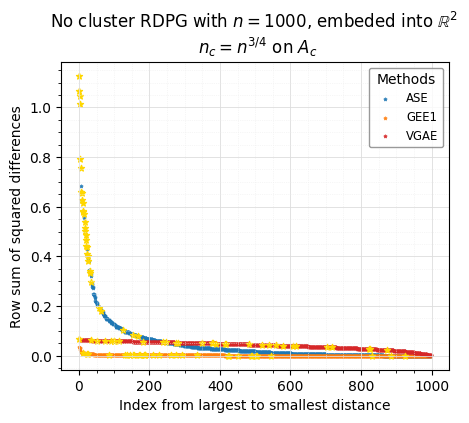

In [67]:

fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(True)
ax.grid(which='major', color='#DDDDDD', linewidth=0.6)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.set_xlabel('Index from largest to smallest distance')
ax.set_ylabel('Row sum of squared differences')
ax.set_title('No cluster RDPG with $n=1000$, embeded into $\mathbb{R}^2$ \n $n_c =n^{3/4}}$ on $A_c$', ###_______________________
             fontsize=12)

plt.scatter(indexs,sortedASE,marker = '*',color = '#1f77b4',alpha = 0.8,s = 4,label = "ASE")
plt.scatter(indexs,sorted_GEE1,marker = '*',color = '#ff7f0e',alpha = 0.8,s = 4,label = "GEE1")
# plt.scatter(indexs,sorted_GEE2,marker = '*',color = '#2ca02c',alpha = 0.8,s = 4,label = 'GEE2')
plt.scatter(indexs,sorted_GAE,marker = '*',color = '#d62728',alpha = 0.8,s = 4,label = "VGAE")
### mark the clique
plt.scatter(highlight_sorted_positions_ase, highlight_sorted_values_ase, 
            marker='*', color='#FFD700', s=20) #, edgecolor='black', label='First 30 (orig.)')
plt.scatter(highlight_sorted_positions_gee1, highlight_sorted_values_gee1, 
            marker='*', color='#FFD700', s=20)
# plt.scatter(highlight_sorted_positions_gee2, highlight_sorted_values_gee2, 
#             marker='*', color='#FFD700', s=20)
plt.scatter(highlight_sorted_positions_gae, highlight_sorted_values_gae, 
            marker='*', color='#FFD700', s=20)

legend = plt.legend(frameon = 1,loc = 1,title="Methods",
                    fontsize='small',fancybox=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')


# a = plt.axes([0.3, 0.6, .2, .2], facecolor='w')
# plt.scatter(indexzoom,zoomase,marker = '*',color = '#1f77b4',alpha = 0.8)
# #plt.title('Zoomed ASE',fontsize = 'small')
# plt.xticks([])
# plt.yticks([])
# mark_inset(ax, a, loc1=2, loc2=4, fc="none", ec="0.6")

plt.show()
#plt.savefig('./plots/rowsum/Ac_r2_n^34_zoom.png')


In [73]:
# CAUTION store the values
Ac_3rdpg_logn = [test1,test2,test3]